# Showroom Culebra — dataset sintético

EDA, modelos baseline y **gráficos para decidir** (ticket, conversión, impulso, lista de 8, tote, canal alojamientos).

- Datos: `data/synthetic/culebra_showroom_daily.csv`
- Regenerar: `python ml/generate_culebra_synthetic.py`
- Mapa de variables: `docs/Variables_Decision_Datasets_Kaggle.md`


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## Cargar dataset

In [2]:
candidates = [
    Path.cwd() / "culebra_showroom_daily.csv",
    Path.cwd() / "data" / "synthetic" / "culebra_showroom_daily.csv",
    Path(__file__).resolve().parent / "culebra_showroom_daily.csv" if "__file__" in dir() else None,
]

csv_path = next((c for c in candidates if c and c.is_file()), None)
if csv_path is None:
    hits = list(Path.cwd().rglob("culebra_showroom_daily.csv"))
    csv_path = hits[0] if hits else None

if csv_path is None:
    raise FileNotFoundError(
        "No se encontró culebra_showroom_daily.csv. "
        "Ejecuta: python ml/generate_culebra_synthetic.py"
    )

print("Dataset path:", csv_path)
df_raw = pd.read_csv(csv_path)
df_raw["date"] = pd.to_datetime(df_raw["date"])
df = df_raw[df_raw["open"] == 1].copy()  # solo días abiertos para métricas operativas
print("Filas totales:", len(df_raw), "| días abiertos:", len(df))
df.head()


Dataset path: c:\Users\chuwi\Documents\culebra\data\synthetic\culebra_showroom_daily.csv
Filas totales: 730 | días abiertos: 302


,date,open,Customer_Footfall,visits,purchases,conversion_rate,Sales_Amount,gmv,avg_ticket_base,avg_ticket_with_impulse,...,distribution_channel,Promotion,Holiday,holiday_or_event,Season,Day_Of_Week,Month,Year,partners_active,Demand_Level
5,2024-01-06,1,18,18,8,0.4444,295.62,295.62,34.49,36.95,...,Direct,Yes,Yes,1,Invierno,Saturday,1,2024,2,Low
6,2024-01-07,1,7,7,3,0.4286,96.22,96.22,30.40,32.07,...,Offline_event,No,No,0,Invierno,Sunday,1,2024,2,Low
7,2024-01-08,1,7,7,3,0.4286,117.26,117.26,37.20,39.09,...,Partner_referral,No,No,0,Invierno,Monday,1,2024,2,Low
12,2024-01-13,1,7,7,1,0.1429,32.63,32.63,31.34,32.63,...,Direct,No,No,0,Invierno,Saturday,1,2024,2,Low
13,2024-01-14,1,15,15,2,0.1333,76.23,76.23,33.80,38.11,...,Direct,Yes,No,0,Invierno,Sunday,1,2024,2,Low


## Resumen rápido

In [3]:
print(df.shape)
print(df.describe(include="number").T.round(2).to_string())
print("Nulos:", int(df.isnull().sum().sum()))


(302, 43)
                         count     mean     std      min      25%      50%      75%      max
open                     302.0     1.00    0.00     1.00     1.00     1.00     1.00     1.00
Customer_Footfall        302.0    15.38    5.99     4.00    11.00    15.00    19.00    31.00
visits                   302.0    15.38    5.99     4.00    11.00    15.00    19.00    31.00
purchases                302.0     5.20    3.04     1.00     3.00     5.00     7.00    18.00
conversion_rate          302.0     0.34    0.15     0.06     0.23     0.33     0.43     0.88
Sales_Amount             302.0   199.37  121.10    30.33   109.84   173.76   274.96   825.74
gmv                      302.0   199.37  121.10    30.33   109.84   173.76   274.96   825.74
avg_ticket_base          302.0    35.80    3.68    28.00    33.33    35.92    38.38    45.50
avg_ticket_with_impulse  302.0    38.19    3.84    29.57    35.67    38.08    40.88    48.95
impulse_attach_pct       302.0    36.50    8.44    12.80    

## Panel de metas (decidir si vamos bien)

Metas del playbook: conversión ≥ 30–35 %, ticket con impulso ≥ 38 €, attach ≥ 40 %, impulso 4–12 €, compra rápida 12–20 €.


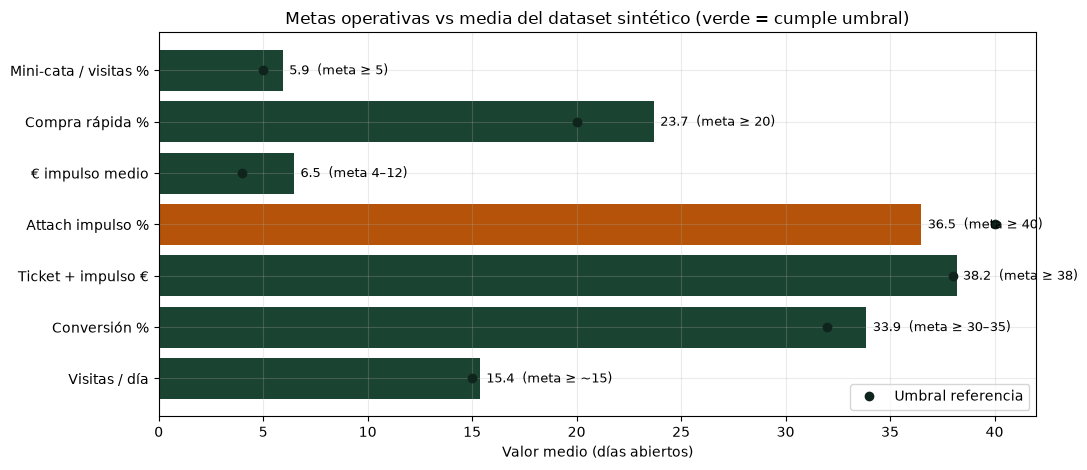

In [4]:
metrics = {
    "Visitas / día": (df["visits"].mean(), 15, "≥ ~15"),
    "Conversión %": (df["conversion_rate"].mean() * 100, 32, "≥ 30–35"),
    "Ticket + impulso €": (df["avg_ticket_with_impulse"].mean(), 38, "≥ 38"),
    "Attach impulso %": (df["impulse_attach_pct"].mean(), 40, "≥ 40"),
    "€ impulso medio": (df["impulse_avg_eur"].mean(), 4, "4–12"),
    "Compra rápida %": (df["quick_buy_pct"].mean(), 20, "≥ 20"),
    "Mini-cata / visitas %": ((df["minicata_u"].sum() / df["visits"].sum()) * 100, 5, "≥ 5"),
}

fig, ax = plt.subplots(figsize=(11, 4.8))
labels = list(metrics.keys())
values = [metrics[k][0] for k in labels]
targets = [metrics[k][1] for k in labels]
colors = ["#1b4332" if v >= t else "#b45309" for v, t in zip(values, targets)]
ax.barh(labels, values, color=colors)
ax.plot(targets, labels, "o", color="#0f241c", label="Umbral referencia")
ax.set_xlabel("Valor medio (días abiertos)")
ax.set_title("Metas operativas vs media del dataset sintético (verde = cumple umbral)")
ax.legend(loc="lower right")
for i, (v, meta) in enumerate(zip(values, [metrics[k][2] for k in labels])):
    ax.text(v + 0.3, i, f"{v:.1f}  (meta {meta})", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## Tendencia mensual — GMV, visitas y conversión

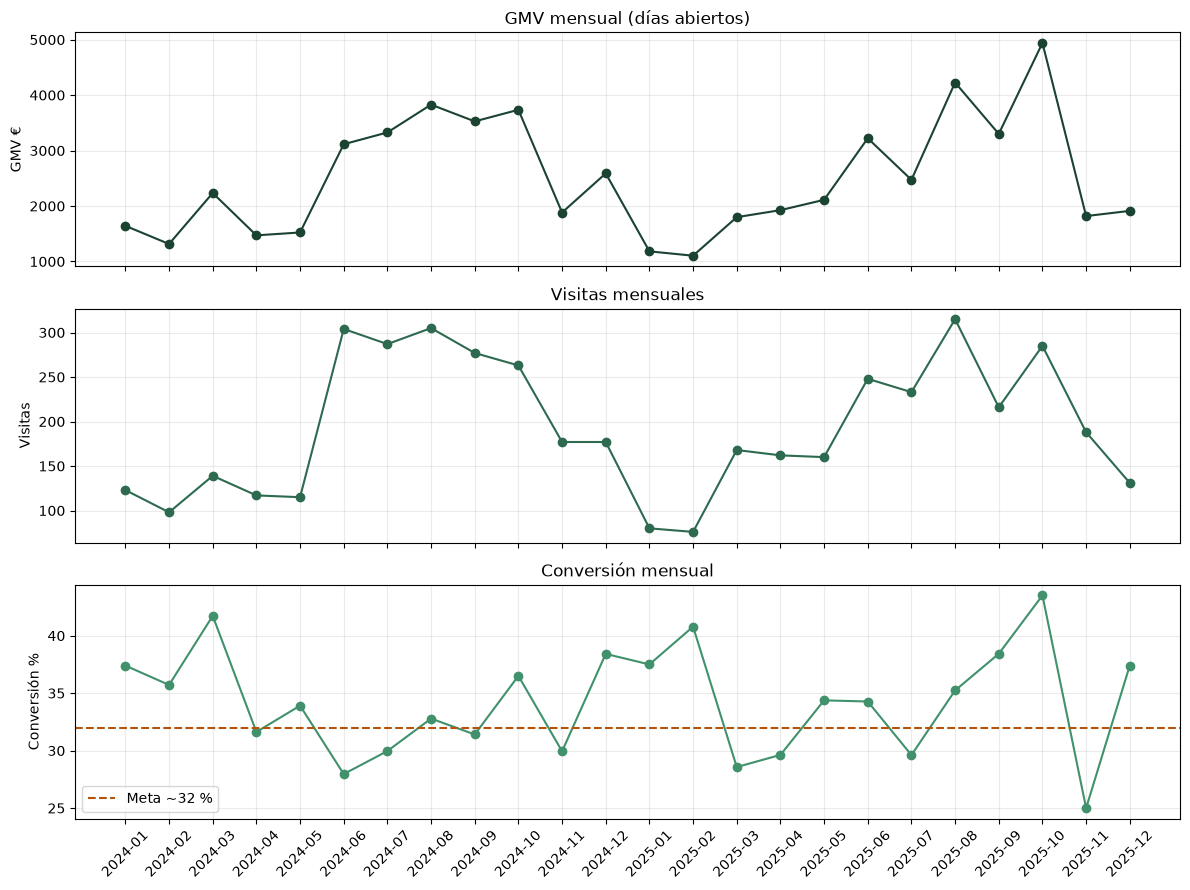

In [5]:
monthly = (
    df.groupby(df["date"].dt.to_period("M"))
    .agg(
        gmv=("gmv", "sum"),
        visits=("visits", "sum"),
        purchases=("purchases", "sum"),
        open_days=("open", "count"),
        ticket=("avg_ticket_with_impulse", "mean"),
    )
    .reset_index()
)
monthly["date"] = monthly["date"].astype(str)
monthly["conversion"] = monthly["purchases"] / monthly["visits"]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(monthly["date"], monthly["gmv"], marker="o", color="#1b4332")
axes[0].set_ylabel("GMV €")
axes[0].set_title("GMV mensual (días abiertos)")
axes[1].plot(monthly["date"], monthly["visits"], marker="o", color="#2d6a4f")
axes[1].set_ylabel("Visitas")
axes[1].set_title("Visitas mensuales")
axes[2].plot(monthly["date"], monthly["conversion"] * 100, marker="o", color="#40916c")
axes[2].axhline(32, color="#b45309", ls="--", label="Meta ~32 %")
axes[2].set_ylabel("Conversión %")
axes[2].set_title("Conversión mensual")
axes[2].legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Estación, festivo y promoción — impacto en ticket y GMV

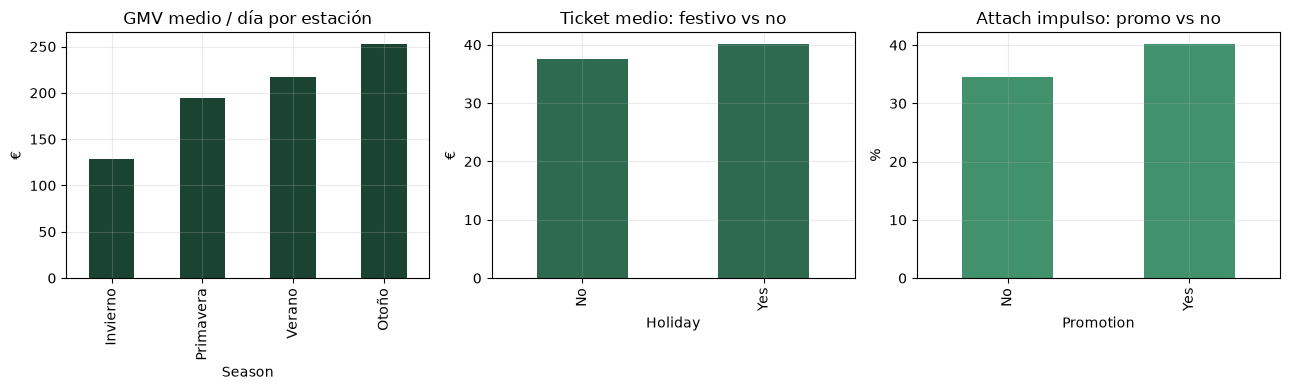

Decisión: priorizar apertura en Verano/Otoño y días Holiday; empujar Promotion para subir attach.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
df.groupby("Season")["gmv"].mean().reindex(["Invierno", "Primavera", "Verano", "Otoño"]).plot(
    kind="bar", ax=axes[0], color="#1b4332"
)
axes[0].set_title("GMV medio / día por estación")
axes[0].set_ylabel("€")

df.groupby("Holiday")["avg_ticket_with_impulse"].mean().plot(kind="bar", ax=axes[1], color="#2d6a4f")
axes[1].set_title("Ticket medio: festivo vs no")
axes[1].set_ylabel("€")

df.groupby("Promotion")["impulse_attach_pct"].mean().plot(kind="bar", ax=axes[2], color="#40916c")
axes[2].set_title("Attach impulso: promo vs no")
axes[2].set_ylabel("%")
plt.tight_layout()
plt.show()

print("Decisión: priorizar apertura en Verano/Otoño y días Holiday; empujar Promotion para subir attach.")


## Impulso en caja — ¿sube el ticket lo suficiente?

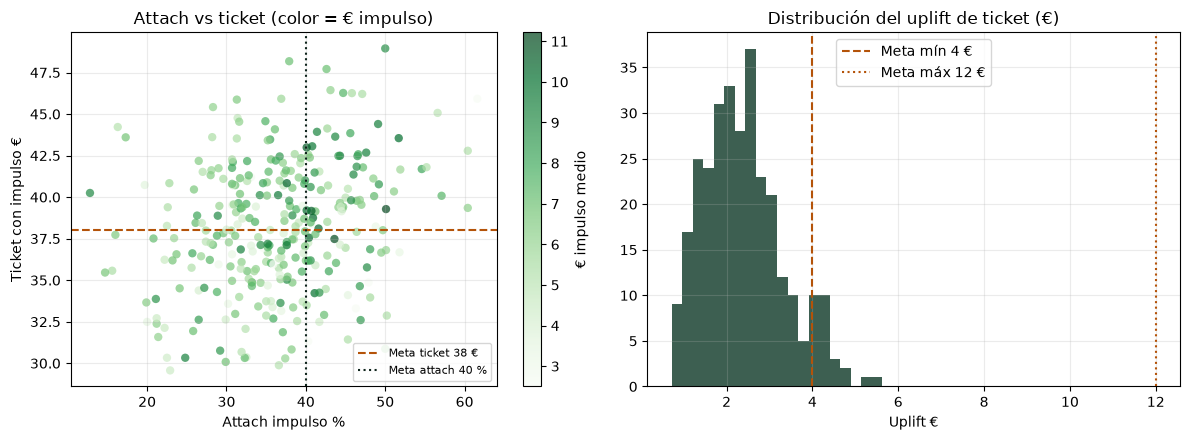

Uplift medio: 2.38 € | % días con uplift en 4–12 €: 8%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sc = axes[0].scatter(
    df["impulse_attach_pct"],
    df["avg_ticket_with_impulse"],
    c=df["impulse_avg_eur"],
    cmap="Greens",
    alpha=0.7,
    edgecolors="none",
)
axes[0].axhline(38, color="#b45309", ls="--", label="Meta ticket 38 €")
axes[0].axvline(40, color="#0f241c", ls=":", label="Meta attach 40 %")
axes[0].set_xlabel("Attach impulso %")
axes[0].set_ylabel("Ticket con impulso €")
axes[0].set_title("Attach vs ticket (color = € impulso)")
axes[0].legend(loc="lower right", fontsize=8)
plt.colorbar(sc, ax=axes[0], label="€ impulso medio")

uplift = df["avg_ticket_with_impulse"] - df["avg_ticket_base"]
axes[1].hist(uplift, bins=20, color="#1b4332", alpha=0.85)
axes[1].axvline(4, color="#b45309", ls="--", label="Meta mín 4 €")
axes[1].axvline(12, color="#b45309", ls=":", label="Meta máx 12 €")
axes[1].set_title("Distribución del uplift de ticket (€)")
axes[1].set_xlabel("Uplift €")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Uplift medio: {uplift.mean():.2f} € | % días con uplift en 4–12 €: {((uplift>=4)&(uplift<=12)).mean():.0%}")


## Lista de 8 — mix de unidades (qué reforzar en caja)

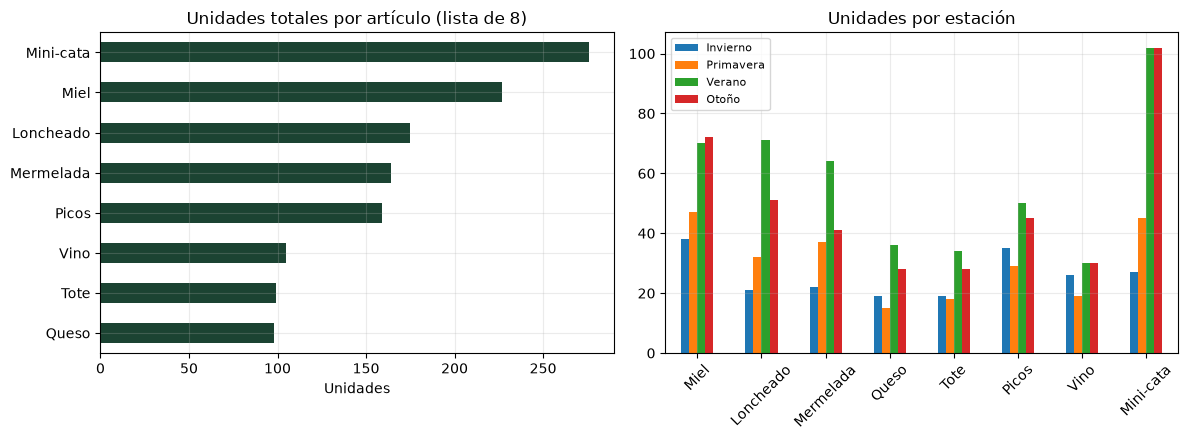

Decisión: lo que menos rota puede necesitar mejor colocación en TPV o formato/precio.
Mini-cata    276
Miel         227
Loncheado    175
Mermelada    164
Picos        159
Vino         105
Tote          99
Queso         98


In [8]:
sku_cols = ["miel_u", "loncheado_u", "mermelada_u", "queso_u", "tote_u", "picos_u", "vino_u", "minicata_u"]
sku_labels = ["Miel", "Loncheado", "Mermelada", "Queso", "Tote", "Picos", "Vino", "Mini-cata"]
sku_sum = df[sku_cols].sum()
sku_sum.index = sku_labels

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sku_sum.sort_values().plot(kind="barh", ax=axes[0], color="#1b4332")
axes[0].set_title("Unidades totales por artículo (lista de 8)")
axes[0].set_xlabel("Unidades")

# Share por estación
sku_by_season = df.groupby("Season")[sku_cols].sum()
sku_by_season.columns = sku_labels
sku_by_season = sku_by_season.reindex(["Invierno", "Primavera", "Verano", "Otoño"])
sku_by_season.T.plot(kind="bar", ax=axes[1], stacked=False)
axes[1].set_title("Unidades por estación")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print("Decisión: lo que menos rota puede necesitar mejor colocación en TPV o formato/precio.")
print(sku_sum.sort_values(ascending=False).to_string())


## Tote bag — stock, ventas y margen propio proxy

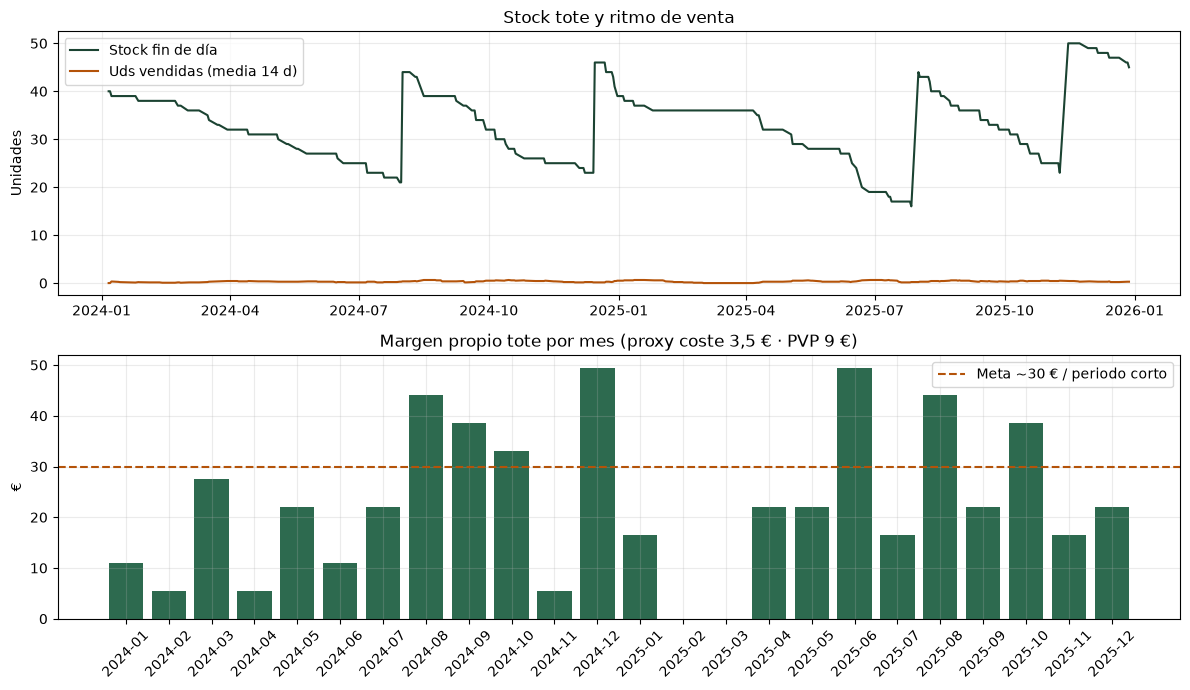

Tote uds totales: 99 | margen proxy: 544 €


In [9]:
tote_cost, tote_pvp = 3.5, 9.0
df["tote_margin_day"] = df["tote_u"] * (tote_pvp - tote_cost)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
axes[0].plot(df["date"], df["tote_stock"], color="#1b4332", label="Stock fin de día")
axes[0].plot(df["date"], df["tote_u"].rolling(14, min_periods=1).mean(), color="#b45309", label="Uds vendidas (media 14 d)")
axes[0].set_title("Stock tote y ritmo de venta")
axes[0].legend()
axes[0].set_ylabel("Unidades")

monthly_tote = df.groupby(df["date"].dt.to_period("M")).agg(u=("tote_u", "sum"), margin=("tote_margin_day", "sum"))
monthly_tote.index = monthly_tote.index.astype(str)
axes[1].bar(monthly_tote.index, monthly_tote["margin"], color="#2d6a4f")
axes[1].axhline(30, color="#b45309", ls="--", label="Meta ~30 € / periodo corto")
axes[1].set_title("Margen propio tote por mes (proxy coste 3,5 € · PVP 9 €)")
axes[1].set_ylabel("€")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
plt.tight_layout()
plt.show()
print(f"Tote uds totales: {df['tote_u'].sum()} | margen proxy: {df['tote_margin_day'].sum():.0f} €")


## Canal alojamientos — referidos y cestas

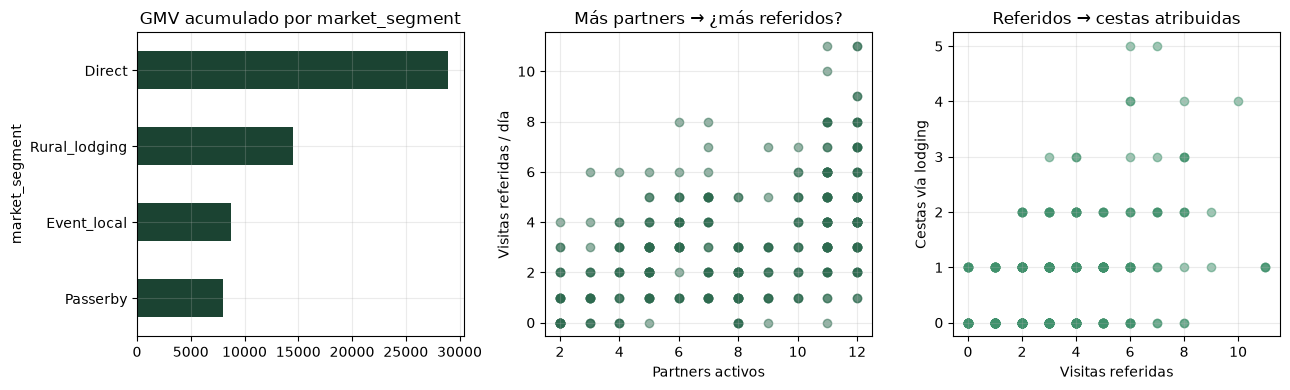

Decisión: si partners_active sube pero referred_visits no, revisar material/script en casas rurales.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
seg = df.groupby("market_segment")["gmv"].sum().sort_values()
seg.plot(kind="barh", ax=axes[0], color="#1b4332")
axes[0].set_title("GMV acumulado por market_segment")

axes[1].scatter(df["partners_active"], df["referred_visits"], alpha=0.5, color="#2d6a4f")
axes[1].set_xlabel("Partners activos")
axes[1].set_ylabel("Visitas referidas / día")
axes[1].set_title("Más partners → ¿más referidos?")

axes[2].scatter(df["referred_visits"], df["baskets_via_lodging"], alpha=0.5, color="#40916c")
axes[2].set_xlabel("Visitas referidas")
axes[2].set_ylabel("Cestas vía lodging")
axes[2].set_title("Referidos → cestas atribuidas")
plt.tight_layout()
plt.show()
print("Decisión: si partners_active sube pero referred_visits no, revisar material/script en casas rurales.")


## Captación y online atribuido

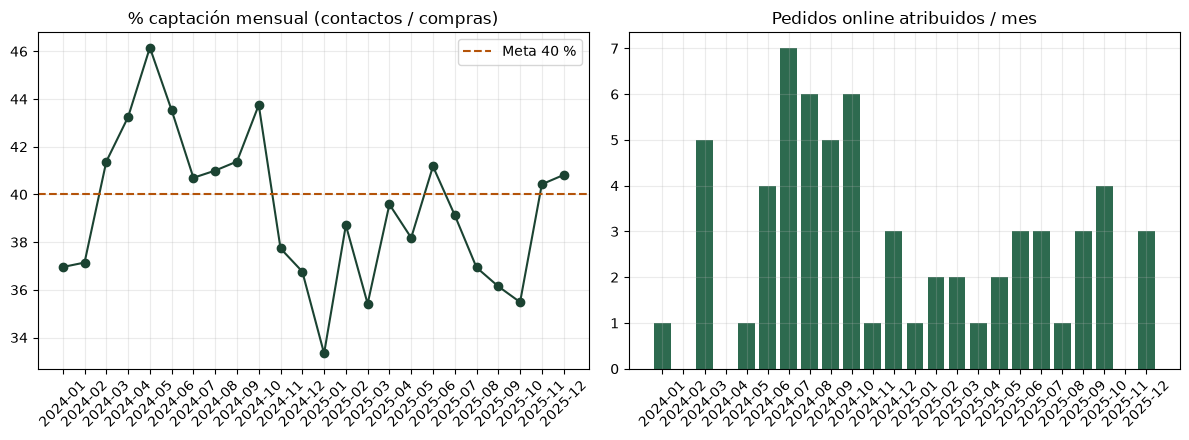

In [11]:
df["capture_pct"] = df["contacts"] / df["purchases"].clip(lower=1)
monthly_c = df.groupby(df["date"].dt.to_period("M")).agg(
    contacts=("contacts", "sum"),
    online=("online_orders_attr", "sum"),
    purchases=("purchases", "sum"),
)
monthly_c.index = monthly_c.index.astype(str)
monthly_c["capture"] = monthly_c["contacts"] / monthly_c["purchases"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(monthly_c.index, monthly_c["capture"] * 100, marker="o", color="#1b4332")
axes[0].axhline(40, color="#b45309", ls="--", label="Meta 40 %")
axes[0].set_title("% captación mensual (contactos / compras)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(monthly_c.index, monthly_c["online"], color="#2d6a4f")
axes[1].set_title("Pedidos online atribuidos / mes")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Correlación entre variables de decisión

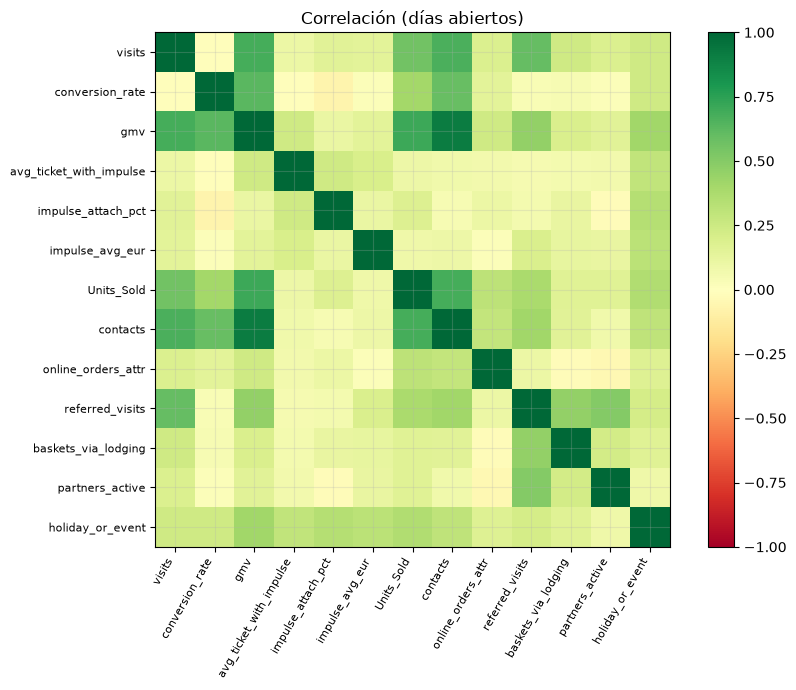

In [12]:
corr_cols = [
    "visits", "conversion_rate", "gmv", "avg_ticket_with_impulse",
    "impulse_attach_pct", "impulse_avg_eur", "Units_Sold",
    "contacts", "online_orders_attr", "referred_visits",
    "baskets_via_lodging", "partners_active", "holiday_or_event",
]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=60, ha="right", fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)
ax.set_title("Correlación (días abiertos)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()


## Modelo: predecir GMV del día (regresión)

MAE: 20.41
R2: 0.904


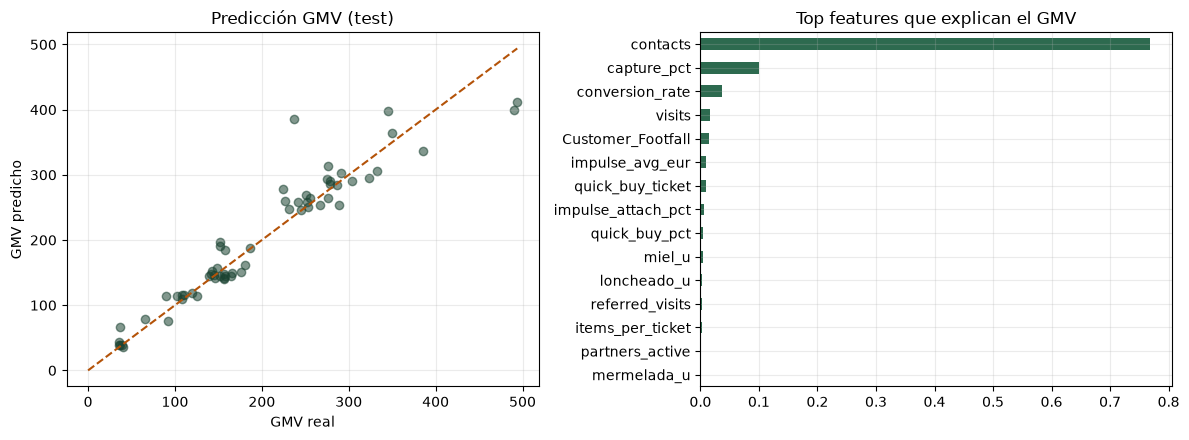

Decisión: las variables más importantes son las palancas a vigilar en el panel /admin/showroom.


In [13]:
feature_drop = ["date", "Sales_Amount", "gmv", "Demand_Level", "Day_Of_Week"]
# Evitar leakage obvio: purchases*ticket ≈ gmv; usamos drivers operativos
X = df.drop(columns=feature_drop + ["purchases", "avg_ticket_base", "avg_ticket_with_impulse", "Units_Sold"], errors="ignore")
# Mantener drivers
keep_hint = [
    "visits", "conversion_rate", "impulse_attach_pct", "impulse_avg_eur",
    "quick_buy_pct", "quick_buy_ticket", "miel_u", "loncheado_u", "mermelada_u",
    "queso_u", "tote_u", "picos_u", "vino_u", "minicata_u", "Inventory_Level",
    "Online_Orders", "contacts", "referred_visits", "baskets_via_lodging",
    "market_segment", "distribution_channel", "Promotion", "Holiday",
    "Season", "Month", "partners_active", "holiday_or_event", "items_per_ticket",
    "campaign_conversions", "online_orders_attr", "Customer_Footfall", "open",
    "tote_stock", "Year", "capture_pct", "tote_margin_day",
]
X = df[[c for c in keep_hint if c in df.columns]].copy()
y = df["gmv"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
print("MAE:", round(mean_absolute_error(y_test, pred), 2))
print("R2:", round(r2_score(y_test, pred), 3))

# Importancia de features
ohe = reg.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical_cols)) if categorical_cols else []
feat_names = cat_names + numeric_cols
importances = pd.Series(reg.named_steps["model"].feature_importances_, index=feat_names)
top = importances.sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test, pred, alpha=0.55, color="#1b4332")
lims = [0, max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, "--", color="#b45309")
axes[0].set_xlabel("GMV real")
axes[0].set_ylabel("GMV predicho")
axes[0].set_title("Predicción GMV (test)")
top.sort_values().plot(kind="barh", ax=axes[1], color="#2d6a4f")
axes[1].set_title("Top features que explican el GMV")
plt.tight_layout()
plt.show()
print("Decisión: las variables más importantes son las palancas a vigilar en el panel /admin/showroom.")


## Modelo: clasificar nivel de demanda (Low / Medium / High)

Accuracy: 0.951
              precision    recall  f1-score   support

         Low       0.95      1.00      0.97        58
      Medium       0.00      0.00      0.00         3

    accuracy                           0.95        61
   macro avg       0.48      0.50      0.49        61
weighted avg       0.90      0.95      0.93        61



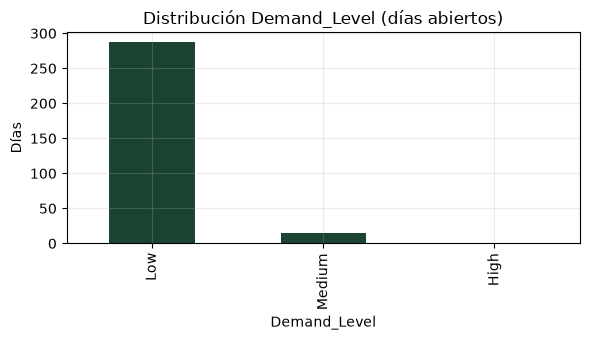

In [14]:
Xc = X.copy()
yc = df["Demand_Level"]
# Solo clases presentes en días abiertos
clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ]
)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)
clf.fit(Xc_train, yc_train)
pred_c = clf.predict(Xc_test)
print("Accuracy:", round(accuracy_score(yc_test, pred_c), 3))
print(classification_report(yc_test, pred_c))

df["Demand_Level"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", color="#1b4332", figsize=(6, 3.5)
)
plt.title("Distribución Demand_Level (días abiertos)")
plt.ylabel("Días")
plt.tight_layout()
plt.show()


## Conclusiones para decidir

1. **Calendario:** concentra apertura y stock en Verano/Otoño y festivos (berrea, Navidad).
2. **Impulso:** si attach < 40 % o uplift fuera de 4–12 €, revisa colocación TPV (miel, loncheado, mermelada, picos, tote).
3. **Lista de 8:** refuerza lo que menos rota; mini-cata debe acercarse a ≥ 5 % visitas.
4. **Tote:** margen propio — no dejes stock muerto; repón cuando sell-through sea sano.
5. **Alojamientos:** partners_active debe correlacionar con referred_visits y cestas; si no, el CRM no convierte.
6. **Online:** captación ≥ 40 % de compradores alimenta `online_orders_attr`.
7. Usa la importancia del RandomForest como checklist de variables en `/admin/showroom`.

*Dataset sintético: sirve para practicar el modelo; recalibra con datos reales del showroom.*
